In [1]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split
import mlflow
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFECV
from pathlib import Path

In [3]:
from sklearn import set_config
set_config(transform_output = "pandas")

In [4]:
pd.set_option('display.max_columns', 100)

In [7]:
current_path = Path.cwd()

root_path = current_path.parent
data_path = root_path / "data" / "interim" / "clean_train.csv"

In [8]:
data = pd.read_csv(data_path)

In [9]:
data.columns.to_list()

['age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'weather',
 'traffic',
 'vehicle_condition',
 'order_type',
 'vehicle_type',
 'multiple_deliveries',
 'is_festival',
 'city_category',
 'time',
 'city',
 'day',
 'month',
 'year',
 'day_of_week',
 'is_weekend',
 'order_time_hour',
 'order_time_of_day',
 'pickup_time_minutes',
 'distance',
 'distance_type']

In [10]:
data.drop(['restaurant_latitude', 'restaurant_longitude', 'delivery_latitude', 'delivery_longitude', 'city',
          'day', 'month', 'year', 'day_of_week', 'order_time_hour'], axis = 1, inplace = True)

In [11]:
# count of duplicate rows
data.duplicated().sum()

np.int64(0)

In [12]:
pd.DataFrame(data.isna().sum())

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
order_type,0
vehicle_type,0
multiple_deliveries,933
is_festival,217
city_category,1135


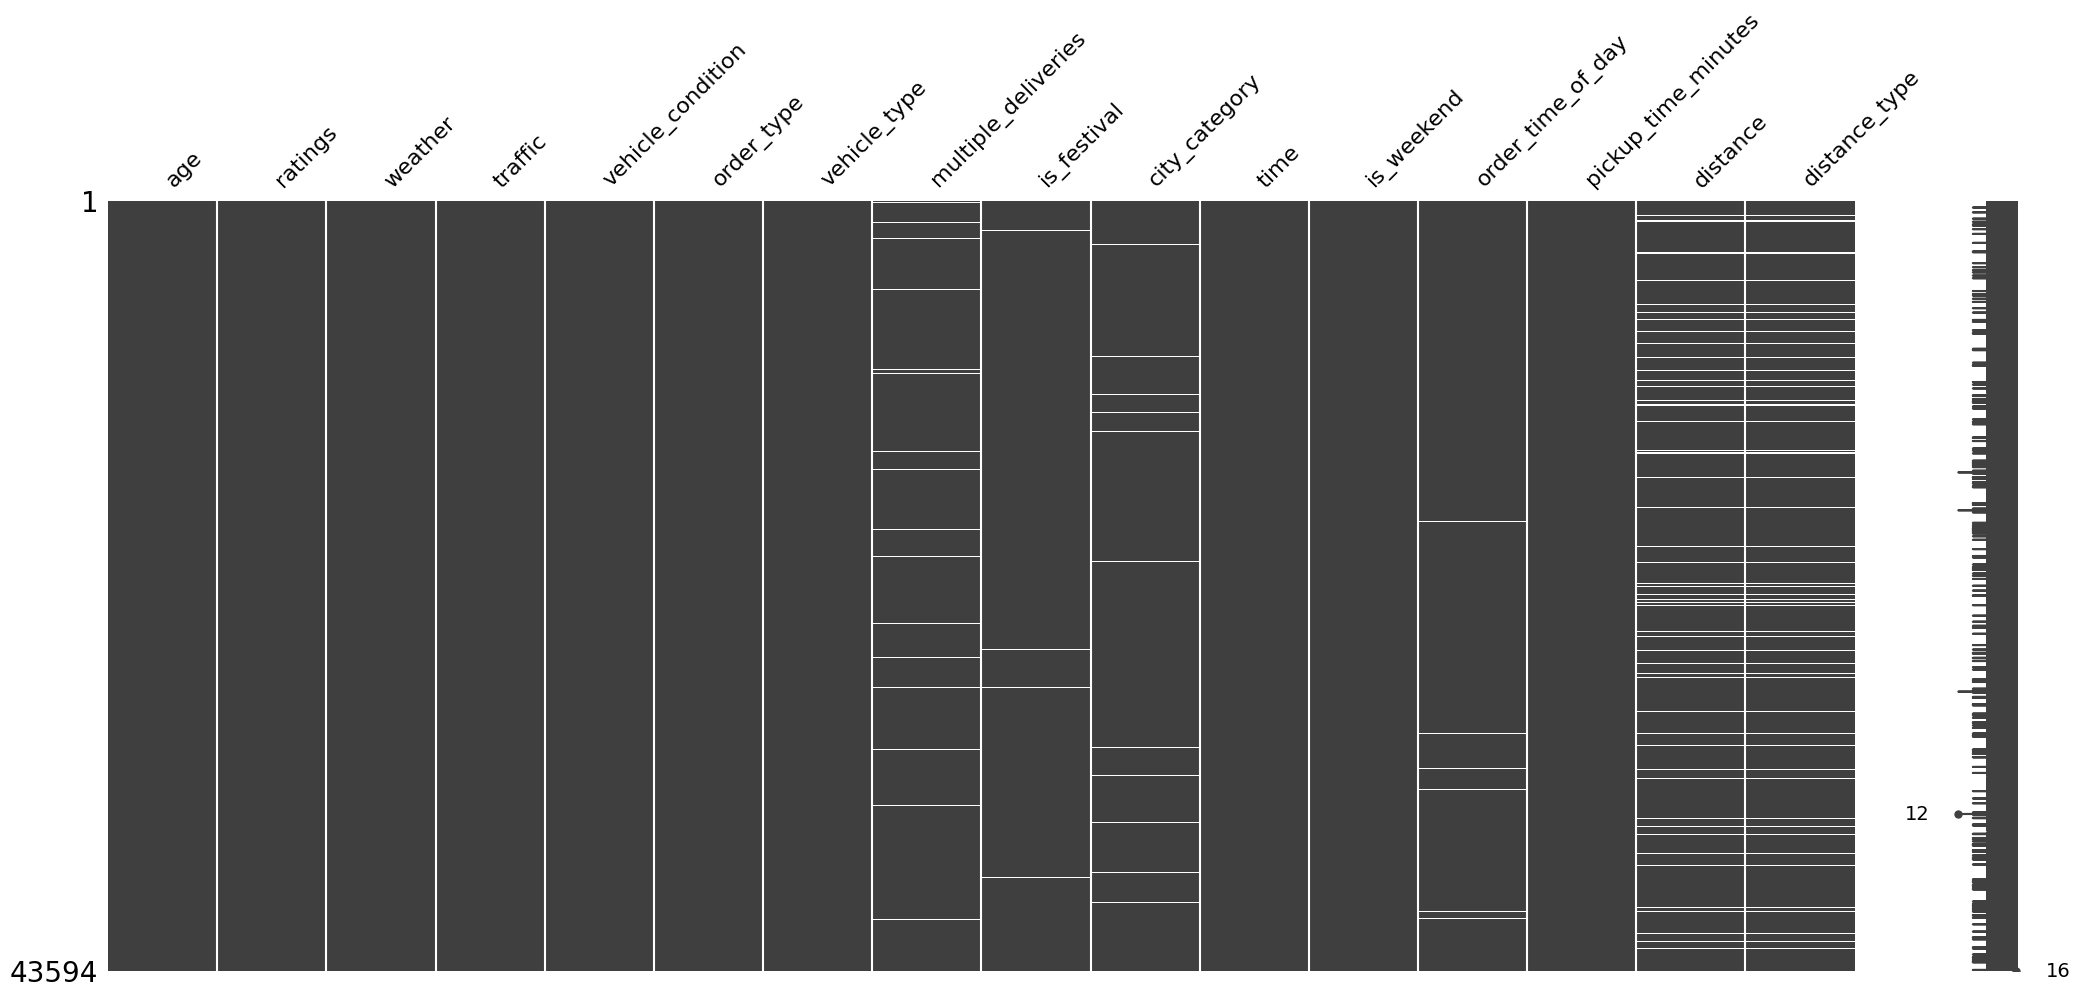

In [13]:
msno.matrix(data)
plt.show()

In [14]:
# column name that have missing values
data.isna().any(axis = 0).loc[lambda x: x].index.to_list()

['multiple_deliveries',
 'is_festival',
 'city_category',
 'order_time_of_day',
 'distance',
 'distance_type']

### Drop Missing Values

In [71]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [72]:
mlflow.set_experiment("Exp 4.1 - Keep Missing value Vs Drop Missing Values")

2025/05/25 20:38:01 INFO mlflow.tracking.fluent: Experiment with name 'Exp 4.1 - Keep Missing value Vs Drop Missing Values' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/398112611315268646', creation_time=1748185681493, experiment_id='398112611315268646', last_update_time=1748185681493, lifecycle_stage='active', name='Exp 4.1 - Keep Missing value Vs Drop Missing Values', tags={}>

In [15]:
temp_df = data.copy().dropna()

In [16]:
X = temp_df.drop(columns='time')
y = temp_df['time']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (30040, 15)
The shape of test data is (7510, 15)


In [19]:
# count of null values for each colm
pd.DataFrame(X_train.isna().sum())

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
order_type,0
vehicle_type,0
multiple_deliveries,0
is_festival,0
city_category,0


In [20]:
# col names in X_train
pd.DataFrame(X_train.columns.to_list())

,0
0,age
1,ratings
2,weather
3,traffic
4,vehicle_condition
5,order_type
6,vehicle_type
7,multiple_deliveries
8,is_festival
9,city_category


In [21]:
len(X_train.columns)

15

In [22]:
# do basic preprocessing
num_cols = ['age', 'ratings', 'pickup_time_minutes', 'distance']

nominal_cat_cols = ['weather', 
                    'order_type',
                    'vehicle_type', 
                    'is_festival',
                    'city_category',
                    'is_weekend',
                    'order_time_of_day']

ordinal_cat_cols = ['traffic', 'distance_type']

In [23]:
len(num_cols + nominal_cat_cols + ordinal_cat_cols)

13

In [24]:
# unique categories in feature
for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['jam' 'low' 'medium' 'high']
distance_type ['medium' 'long' 'very_long' 'short']


In [25]:
# generate order for ordinal encoding

traffic_order = ["low", "medium", "high", "jam"]
distance_type_order = ["short", "medium", "long", "very_long"]

In [26]:
# build a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order]), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'order_type', 'vehicle_type',
                                  'is_festival', 'city_category', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']]),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [27]:
# transform the data

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

X_train_trans

,age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,order_type_drinks,order_type_meal,order_type_snack,vehicle_type_motorcycle,vehicle_type_scooter,is_festival_yes,city_category_semi-urban,city_category_urban,is_weekend_1,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type,vehicle_condition,multiple_deliveries
32157,0.578947,0.80,0.996552,0.318832,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,1.0,2,0.0
27718,0.157895,0.92,0.993103,0.563942,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,2.0,2,1.0
39525,0.947368,0.64,1.000000,0.800317,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,3.0,2,3.0
24504,1.000000,0.44,1.000000,0.932797,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,3.0,2,1.0
761,0.842105,0.96,1.000000,0.162395,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19502,0.210526,0.80,1.000000,0.960873,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,0,0.0
7300,0.736842,0.88,0.996552,0.466449,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0,1.0
13107,0.789474,0.76,0.993103,0.641238,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,2.0,0,2.0
1004,0.526316,1.00,1.000000,0.389461,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,1.0


In [28]:
# power transform time colm

pt = PowerTransformer()
y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [29]:
pt.lambdas_

array([0.3197993])

In [30]:
y_train_pt.sample(5)

,x0
1915,-1.842186
29637,0.050443
4878,0.260343
6853,-0.403440
14135,1.266635


In [31]:
# random forest regressor model training
rf = RandomForestRegressor()
rf.fit(X_train_trans,y_train_pt.values.ravel())

RandomForestRegressor()

In [32]:
# get the predictions
y_pred_train = rf.predict(X_train_trans)
y_pred_test = rf.predict(X_test_trans)

In [33]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [34]:
# mae error
print(f"The train MAE error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test MAE error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train MAE error is 1.16 minutes
The test MAE error is 3.11 minutes


In [35]:
# r2 score
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.98
The test r2 score is 0.82


In [36]:
# cross val score
scores = cross_val_score(rf,X_train_trans,y_train_pt.values.ravel(), cv = 5, scoring = "r2", n_jobs = -1)
scores

array([0.80381647, 0.81807676, 0.80550052, 0.80402778, 0.80607698])

In [37]:
# mean score
scores.mean() * 100

np.float64(80.74997018244092)

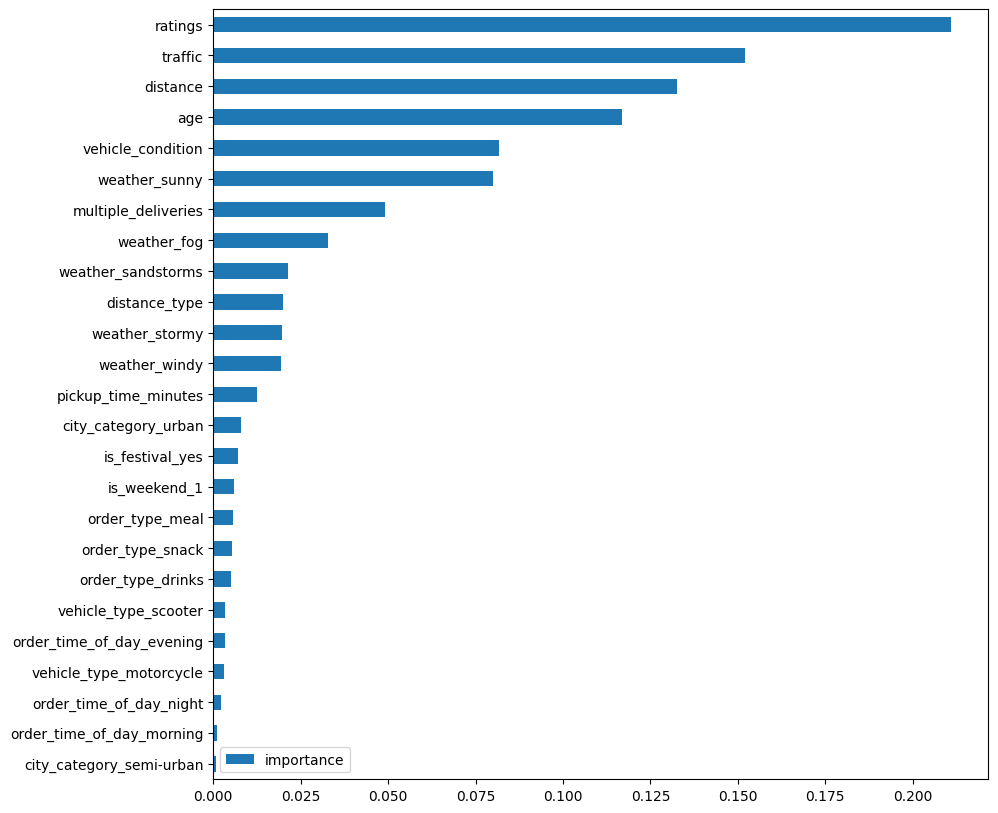

In [38]:
# feature importance plot
(
    pd.DataFrame(rf.feature_importances_,
             index=X_train_trans.columns,
             columns=["importance"])
    .sort_values(by="importance")
    .plot(kind='barh',figsize=(10,10))
)
plt.show()

In [107]:
# log experiment

with mlflow.start_run(run_name = "Drop Missing Values Run"):
    # mlflow log experiment type
    mlflow.log_param("experiment_type", "Drop Missing Values Run")
    # log model params
    mlflow.log_params(rf.get_params())

    # log metrics
    mlflow.log_metric("training_error", mean_absolute_error(y_train,y_pred_train_org))
    mlflow.log_metric("test_error", mean_absolute_error(y_test,y_pred_test_org))
    mlflow.log_metric("training_r2", r2_score(y_train,y_pred_train_org))
    mlflow.log_metric("test_r2", r2_score(y_test,y_pred_test_org))
    mlflow.log_metric("cross_val", scores.mean())

🏃 View run Drop Missing Values Run at: http://127.0.0.1:5000/#/experiments/398112611315268646/runs/3b4f9ba282fd43278c01343a66b70abd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/398112611315268646


In [39]:
rf = RandomForestRegressor()

# Recursive Feature Elimination with Cross-Validation
rfecv = RFECV(
    estimator = rf,
    step = 10,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1,
    verbose = 2
)

rfecv.fit(X_train_trans,y_train_pt.values.ravel())

RFECV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1, scoring='r2', step=10,
      verbose=2)

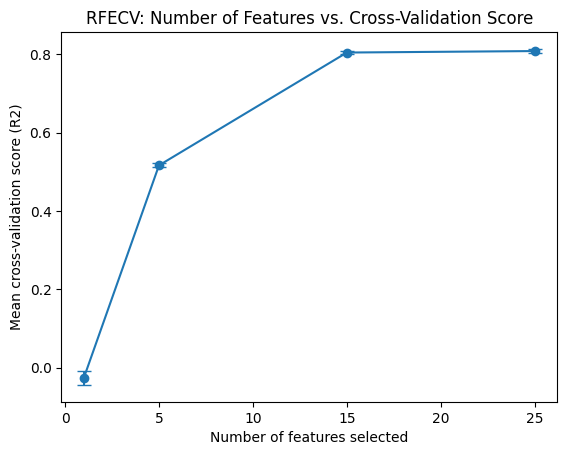

In [40]:
cv_results = pd.DataFrame(rfecv.cv_results_)

plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean cross-validation score (R2)")
plt.errorbar(
    x = cv_results["n_features"],
    y = cv_results["mean_test_score"],
    yerr = cv_results["std_test_score"],
    marker = 'o',
    capsize = 5
)

plt.title("RFECV: Number of Features vs. Cross-Validation Score")
plt.show()

In [41]:
# colm names
rfecv.get_feature_names_out()

array(['age', 'ratings', 'pickup_time_minutes', 'distance', 'weather_fog',
       'weather_sandstorms', 'weather_stormy', 'weather_sunny',
       'weather_windy', 'order_type_drinks', 'order_type_meal',
       'order_type_snack', 'vehicle_type_motorcycle',
       'vehicle_type_scooter', 'is_festival_yes',
       'city_category_semi-urban', 'city_category_urban', 'is_weekend_1',
       'order_time_of_day_evening', 'order_time_of_day_morning',
       'order_time_of_day_night', 'traffic', 'distance_type',
       'vehicle_condition', 'multiple_deliveries'], dtype=object)

In [42]:
# RandomForestRegressor model

rf = RandomForestRegressor()
rf.fit(rfecv.transform(X_train_trans),y_train_pt.values.ravel())

RandomForestRegressor()

In [43]:
# get the predictions
y_pred_train = rf.predict(rfecv.transform(X_train_trans))
y_pred_test = rf.predict(rfecv.transform(X_test_trans))

In [44]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [45]:
# mae error

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 1.15 minutes
The test error is 3.11 minutes


In [46]:
# r2 score

print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.98
The test r2 score is 0.82


In [47]:
# cross val score

scores = cross_val_score(rf,rfecv.transform(X_train_trans),y_train_pt.values.ravel(), cv = 5, scoring = "r2", n_jobs = -1)
scores

array([0.80338087, 0.81677887, 0.80442067, 0.80317692, 0.80680764])

In [48]:
scores.mean()

np.float64(0.8069129959269595)

In [49]:
rf.feature_importances_

array([0.11601158, 0.21083574, 0.01260019, 0.13124431, 0.03320593,
       0.02160253, 0.01841568, 0.08012574, 0.01979685, 0.00520621,
       0.0055702 , 0.00530202, 0.00304615, 0.00331702, 0.00691382,
       0.00083461, 0.00780929, 0.00579878, 0.00342654, 0.00118178,
       0.00218207, 0.15186194, 0.02124687, 0.0818648 , 0.05059933])

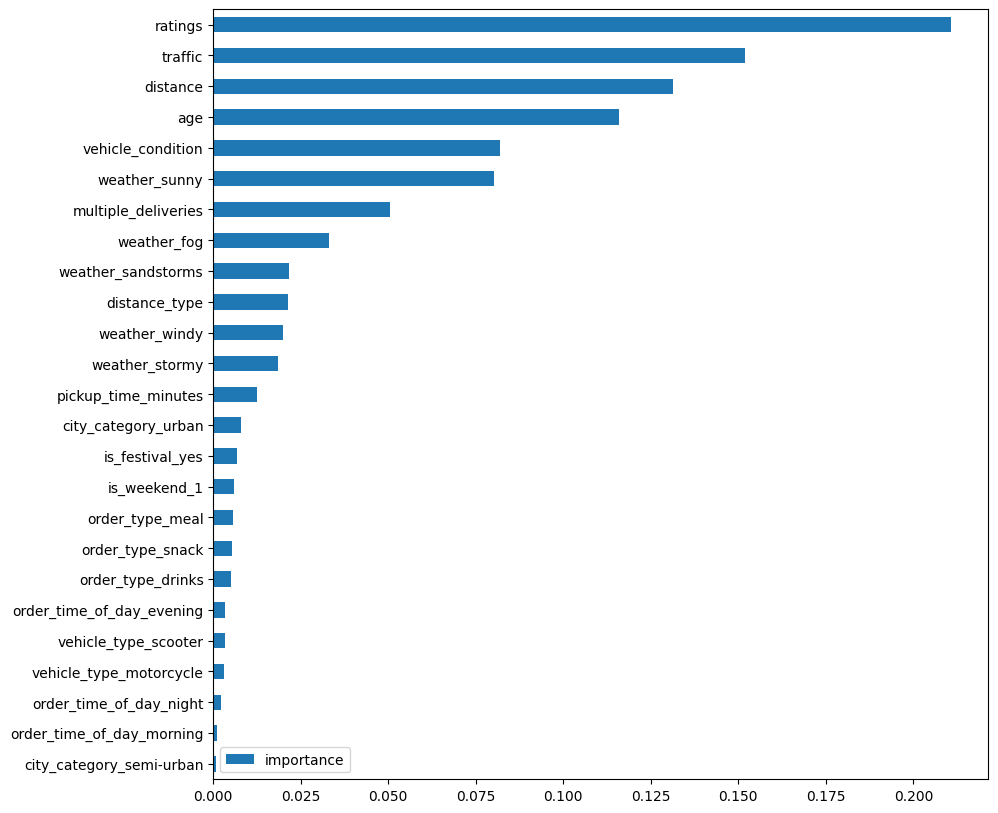

In [50]:
(
    pd.DataFrame(rf.feature_importances_,
             index = rfecv.transform(X_train_trans).columns,
             columns = ["importance"])
    .sort_values(by = "importance")
    .plot(kind = 'barh', figsize = (10,10))
)
plt.show()

### Impute Missing values

In [51]:
temp_df = data.copy()

In [52]:
# split into X and y
X = temp_df.drop(columns='time')
y = temp_df['time']

X

,age,ratings,weather,traffic,vehicle_condition,order_type,vehicle_type,multiple_deliveries,is_festival,city_category,is_weekend,order_time_of_day,pickup_time_minutes,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,1,morning,15.0,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,0,evening,5.0,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,1,morning,15.0,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,0,evening,10.0,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,1,afternoon,15.0,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43589,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,0,morning,10.0,1.489846,short
43590,21.0,4.6,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,0,evening,15.0,NaN,NaN
43591,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,0,night,-1425.0,4.657195,short
43592,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,0,afternoon,5.0,6.232393,medium


In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [54]:
# size and shape of data
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (34875, 15)
The shape of test data is (8719, 15)


In [55]:
# missing values in train data
X_train.isna().sum()

age                       0
ratings                   0
weather                   0
traffic                   0
vehicle_condition         0
order_type                0
vehicle_type              0
multiple_deliveries     756
is_festival             171
city_category           921
is_weekend                0
order_time_of_day       337
pickup_time_minutes       0
distance               2887
distance_type          2887
dtype: int64

In [56]:
# power transform target column

pt = PowerTransformer()
y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [57]:
(
    X_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2) * 100
)

np.float64(14.000000000000002)

### **Imputation Pipeline**

In [58]:
nominal_cat_cols

['weather',
 'order_type',
 'vehicle_type',
 'is_festival',
 'city_category',
 'is_weekend',
 'order_time_of_day']

In [59]:
X_train.isna().sum()

age                       0
ratings                   0
weather                   0
traffic                   0
vehicle_condition         0
order_type                0
vehicle_type              0
multiple_deliveries     756
is_festival             171
city_category           921
is_weekend                0
order_time_of_day       337
pickup_time_minutes       0
distance               2887
distance_type          2887
dtype: int64

In [60]:
# features to impute

features_to_fill_mode = ['multiple_deliveries', 'is_festival', 'city_category']
features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]

features_to_fill_missing

['weather', 'order_type', 'vehicle_type', 'is_weekend', 'order_time_of_day']

In [61]:
simple_imputer = ColumnTransformer(transformers = [
    ("mode_imputer", SimpleImputer(strategy = "most_frequent"), features_to_fill_mode),
    ("missing_imputer", SimpleImputer(strategy = "constant", fill_value = "missing"), features_to_fill_missing)
], remainder = "passthrough" , n_jobs = -1, force_int_remainder_cols = False, verbose_feature_names_out = False)

simple_imputer

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('mode_imputer',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['multiple_deliveries', 'is_festival',
                                  'city_category']),
                                ('missing_imputer',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['weather', 'order_type', 'vehicle_type',
                                  'is_weekend', 'order_time_of_day'])],
                  verbose_feature_names_out=False)

In [62]:
simple_imputer.fit_transform(X_train)

,multiple_deliveries,is_festival,city_category,weather,order_type,vehicle_type,is_weekend,order_time_of_day,age,ratings,traffic,vehicle_condition,pickup_time_minutes,distance,distance_type
3938,0.0,no,metropolitian,sunny,drinks,motorcycle,1,afternoon,20.0,4.8,medium,1,5.0,8.953006,medium
3252,1.0,no,metropolitian,sunny,buffet,scooter,0,night,38.0,4.4,jam,2,10.0,17.098061,very_long
40782,0.0,no,metropolitian,stormy,drinks,motorcycle,0,morning,34.0,4.4,low,0,15.0,3.108984,short
41197,1.0,no,metropolitian,sandstorms,buffet,scooter,1,morning,25.0,5.0,low,1,15.0,1.552700,short
1510,1.0,no,metropolitian,cloudy,snack,scooter,0,morning,20.0,5.0,high,2,15.0,3.064487,short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,0.0,no,urban,cloudy,drinks,motorcycle,1,night,22.0,4.7,low,0,-1425.0,10.866262,long
11284,1.0,no,metropolitian,cloudy,drinks,scooter,0,evening,28.0,4.8,jam,2,10.0,12.255818,long
38158,2.0,no,metropolitian,cloudy,meal,motorcycle,0,evening,28.0,5.0,medium,0,5.0,10.703215,long
860,1.0,no,urban,windy,snack,motorcycle,1,morning,38.0,4.8,low,1,5.0,1.532253,short


In [63]:
simple_imputer.fit_transform(X_train).isna().sum()

multiple_deliveries       0
is_festival               0
city_category             0
weather                   0
order_type                0
vehicle_type              0
is_weekend                0
order_time_of_day         0
age                       0
ratings                   0
traffic                   0
vehicle_condition         0
pickup_time_minutes       0
distance               2887
distance_type          2887
dtype: int64

In [64]:
# knn imputer
knn_imputer = KNNImputer(n_neighbors=5)

In [65]:
data.sample()

,age,ratings,weather,traffic,vehicle_condition,order_type,vehicle_type,multiple_deliveries,is_festival,city_category,time,is_weekend,order_time_of_day,pickup_time_minutes,distance,distance_type
27721,31.0,4.7,sandstorms,jam,1,buffet,motorcycle,1.0,no,metropolitian,27,1,night,10.0,4.589835,short


In [66]:
# numerical, nominal, ordinal features

num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather','order_type',
                    'vehicle_type',"is_festival",
                    "city_category",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [67]:
# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]
distance_type_order = ["short","medium","long","very_long"]

In [68]:
# unique categories the ordinal columns

for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['medium' 'jam' 'low' 'high']
distance_type ['medium' 'very_long' 'short' 'long' nan]


In [69]:
# building a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop = "first", handle_unknown = "ignore",
                                     sparse_output = False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories = [traffic_order, distance_type_order],
                                      encoded_missing_value = -999,
                                      handle_unknown = "use_encoded_value",
                                      unknown_value = -1), ordinal_cat_cols)
],remainder = "passthrough", n_jobs = -1, force_int_remainder_cols = False, verbose_feature_names_out = False)


preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'order_type', 'vehicle_type',
                                  'is_festival', 'city_category', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [70]:
preprocessor.fit_transform(X_train)

,age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,order_type_drinks,order_type_meal,order_type_snack,vehicle_type_motorcycle,vehicle_type_scooter,is_festival_yes,is_festival_nan,city_category_semi-urban,city_category_urban,city_category_nan,is_weekend_1,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,order_time_of_day_nan,traffic,distance_type,vehicle_condition,multiple_deliveries
3938,0.000000,0.92,0.993103,0.383910,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1,0.0
3252,0.947368,0.76,0.996552,0.801510,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,3.0,2,1.0
40782,0.736842,0.76,1.000000,0.084284,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.0
41197,0.263158,1.00,1.000000,0.004493,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1.0
1510,0.000000,1.00,1.000000,0.082003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,0.105263,0.88,0.006897,0.482003,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,0,0.0
11284,0.421053,0.92,0.996552,0.553246,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,2.0,2,1.0
38158,0.421053,1.00,0.993103,0.473644,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,0,2.0
860,0.947368,0.92,0.993103,0.003445,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1.0


In [71]:
preprocessor.fit_transform(X_train).isna().sum().loc[lambda ser : ser.ge(1)]

distance               2887
multiple_deliveries     756
dtype: int64

In [72]:
processing_pipeline = Pipeline(steps=[
                                ("simple_imputer", simple_imputer),
                                ("preprocess", preprocessor),
                                ("knn_imputer", knn_imputer)
                            ])

processing_pipeline

Pipeline(steps=[('simple_imputer',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('mode_imputer',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['multiple_deliveries',
                                                   'is_festival',
                                                   'city_category']),
                                                 ('missing_imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant'),
                                                  ['weather', 'order_type',
                                                   'vehicle_...
                                                   'is_festival',
                                                   'city_category',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False)),
                ('knn_imputer', KNNImputer())])

In [73]:
model_pipe = Pipeline(steps=[
                                ("preprocessing", processing_pipeline),
                                ("model", rf)
                            ])

model_pipe

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'is_festival',
                                                                    'city_category']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),...
                                                                    'is_weekend',
                                                                    'order_time_of_day']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', RandomForestRegressor())])

In [74]:
# fit the pipeline on data
model_pipe.fit(X_train,y_train_pt.values.ravel())

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'is_festival',
                                                                    'city_category']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),...
                                                                    'is_weekend',
                                                                    'order_time_of_day']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', RandomForestRegressor())])

In [75]:
# get the predictions
y_pred_train = model_pipe.predict(X_train)
y_pred_test = model_pipe.predict(X_test)

In [76]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [77]:
# mae error

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 1.18 minutes
The test error is 3.18 minutes


In [78]:
# r2 score

print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.97
The test r2 score is 0.82


In [79]:
# calculate the cross val score

scores = cross_val_score(model_pipe, X_train, y_train_pt.values.ravel(), cv = 5, scoring = "r2", n_jobs = -1)
scores

array([0.80426449, 0.79606462, 0.79414822, 0.79655371, 0.79508068])

In [80]:
# mean score
scores.mean()

np.float64(0.797222344047853)

Fitting estimator with 25 features.
Fitting estimator with 15 features.
Fitting estimator with 5 features.
Fitting estimator with 25 features.
Fitting estimator with 15 features.
Fitting estimator with 5 features.
Fitting estimator with 25 features.
Fitting estimator with 15 features.
Fitting estimator with 5 features.


In [151]:
# log experiment

with mlflow.start_run(run_name="Impute Missing Values"):
    # mlflow log experiment type
    mlflow.log_param("experiment_type","Impute Missing Values")
    # log model params
    mlflow.log_params(rf.get_params())

    # log metrics
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train_org))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test_org))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train_org))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test_org))
    mlflow.log_metric("cross_val",scores.mean())

🏃 View run Impute Missing Values at: http://127.0.0.1:5000/#/experiments/398112611315268646/runs/20694cf3a09945be96189c5dd8d60d64
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/398112611315268646


In [104]:
data.to_csv('data_processed_v2.csv', index=False)